In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pennylane as qml
from pennylane.qnn import TorchLayer
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

In [4]:
hep_imgs = np.load("hep_train_images.npy")    # shape [N, H, W], float in [0,1]
hep_imgs = (hep_imgs * 2.0) - 1.0             # rescale → [–1,1]
hep_imgs = hep_imgs[:, None, :, :]            # add channel dim → [N,1,H,W]
hep_tensor = torch.from_numpy(hep_imgs).float()
print("HEP dataset size:", len(hep_tensor))  # Total number of training images


HEP dataset size: 100000


Epoch  1 | D-loss: 0.6961 | G-loss: 0.7723
Epoch  2 | D-loss: 0.6956 | G-loss: 0.7691
Epoch  3 | D-loss: 0.6951 | G-loss: 0.7658
Epoch  4 | D-loss: 0.6948 | G-loss: 0.7632
Epoch  5 | D-loss: 0.6943 | G-loss: 0.7604
Epoch  6 | D-loss: 0.6938 | G-loss: 0.7575
Epoch  7 | D-loss: 0.6935 | G-loss: 0.7550
Epoch  8 | D-loss: 0.6931 | G-loss: 0.7527
Epoch  9 | D-loss: 0.6928 | G-loss: 0.7502
Epoch 10 | D-loss: 0.6923 | G-loss: 0.7479


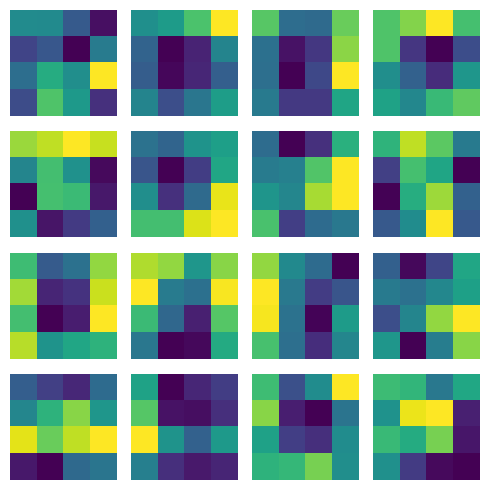

In [ ]:

batch_size = 128
latent_dim = 100
n_qubits   = 8       # 8 qubits
q_depth    = 3
lr         = 1e-4
n_epochs   = 10
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hep_imgs = np.load("hep_train_images.npy")        # [N,H,W]
hep_imgs = hep_imgs * 2 - 1                       # → [-1,1]
hep_imgs = hep_imgs[:, None, :, :]                # → [N,1,H,W]
hep_tensor = torch.from_numpy(hep_imgs).float()
hep_tensor = hep_tensor[:10000]

train_loader = DataLoader(
    TensorDataset(hep_tensor),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)


dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qcircuit(angles, weights):
    # RX/RY encoding
    for i in range(n_qubits):
        qml.RX(angles[i], wires=i)
        qml.RY(angles[i + n_qubits], wires=i)
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]


class Generator(nn.Module):
    def __init__(self, img_size):
        super().__init__()
        self.init_size = img_size // 4
        self.fc    = nn.Linear(latent_dim, 128 * self.init_size**2)
        self.pre_q = nn.Linear(128, 2 * n_qubits)
        # one shared quantum weight tensor
        self.q_weights = nn.Parameter(torch.randn(q_depth, n_qubits))
        self.post_q= nn.Linear(n_qubits, 128)
        self.upsample = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 1, 3, padding=1),
            nn.Tanh(),
        )

    def forward(self, z):
        b = z.size(0)
        x = self.fc(z).view(b, 128, self.init_size, self.init_size)
        feat   = x.mean(dim=[2,3])                         # [b,128]
        angles = torch.tanh(self.pre_q(feat)) * torch.pi   # [b,2*n_qubits]

        # manual quantum loop
        qouts = []
        for a in angles:
            # run circuit on CPU, get Python list of floats
            out_list = qcircuit(a.to('cpu'), self.q_weights.to('cpu'))
            # convert to tensor on GPU
            out_tensor = torch.tensor(out_list, dtype=torch.float32, device=device)
            qouts.append(out_tensor)
        q_out = torch.stack(qouts, dim=0)                  # [b,n_qubits]

        fusion = self.post_q(q_out).view(b,128,1,1)
        x = x * (1 + fusion)
        return self.upsample(x)

class Discriminator(nn.Module):
    def __init__(self, img_size):
        super().__init__()
        self.down = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, True),
            nn.Flatten(),
        )
        feat_dim = 32 * (img_size // 4) * (img_size // 4)
        self.fc1   = nn.Linear(feat_dim, 128)
        self.pre_q = nn.Linear(128, 2 * n_qubits)
        self.q_weights = nn.Parameter(torch.randn(q_depth, n_qubits))
        self.post_q= nn.Linear(n_qubits, 1)

    def forward(self, img):
        b = img.size(0)
        x = self.down(img)
        feat   = torch.relu(self.fc1(x))                   # [b,128]
        angles = torch.tanh(self.pre_q(feat)) * torch.pi   # [b,2*n_qubits]

        qouts = []
        for a in angles:
            out_list   = qcircuit(a.to('cpu'), self.q_weights.to('cpu'))
            out_tensor = torch.tensor(out_list, dtype=torch.float32, device=device)
            qouts.append(out_tensor)
        q_out = torch.stack(qouts, dim=0)                  # [b,n_qubits]

        return torch.sigmoid(self.post_q(q_out))

_, _, H, W = hep_tensor.shape
img_size = H
G = Generator(img_size).to(device)
D = Discriminator(img_size).to(device)

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5,0.999))
criterion = nn.BCELoss()

for epoch in range(1, n_epochs+1):
    g_loss_acc = d_loss_acc = 0.0
    for (real_imgs,) in train_loader:
        real = real_imgs.to(device)
        b = real.size(0)
        ones  = torch.ones(b,1, device=device)
        zeros = torch.zeros(b,1, device=device)

        opt_D.zero_grad()
        d_real   = D(real)
        loss_r   = criterion(d_real, ones)
        z        = torch.randn(b, latent_dim, device=device)
        d_fake   = D(G(z).detach())
        loss_f   = criterion(d_fake, zeros)
        d_loss   = 0.5 * (loss_r + loss_f)
        d_loss.backward()
        opt_D.step()

        opt_G.zero_grad()
        z2       = torch.randn(b, latent_dim, device=device)
        g_loss   = criterion(D(G(z2)), ones)
        g_loss.backward()
        opt_G.step()

        d_loss_acc += d_loss.item()
        g_loss_acc += g_loss.item()

    print(f"Epoch {epoch:2d} | D-loss: {d_loss_acc/len(train_loader):.4f} | "
          f"G-loss: {g_loss_acc/len(train_loader):.4f}")

G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    samples = G(z).cpu().squeeze().numpy()

fig, axs = plt.subplots(4,4, figsize=(5,5))
for ax, img in zip(axs.flatten(), samples):
    ax.imshow(img, cmap="viridis")
    ax.axis("off")
plt.tight_layout()
plt.show()


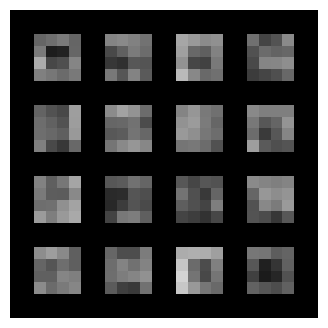

FID:              378.89


c:\Users\maya\gsoc\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Inception Score:  1.06 ± 0.01


In [ ]:

G.eval()


with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    samples = G(z).cpu().clamp(-1,1).add(1).div(2).squeeze(1)  # → [16,H,W]

grid = make_grid(samples.unsqueeze(1), nrow=4)  # [1,GH,GW]
arr  = grid.permute(1,2,0).squeeze()             # → [GH,GW]

plt.figure(figsize=(4,4))
plt.imshow(arr)
plt.axis("off")
plt.show()

real_batch = next(iter(train_loader))[0]               # [B,1,H,W]
real = real_batch.to(device).clamp(-1,1).add(1).div(2) # → [0,1]

real_3c = real.repeat(1,3,1,1)
real_3c = F.interpolate(real_3c, size=(299,299), mode='bilinear')

with torch.no_grad():
    z2   = torch.randn(real.size(0), latent_dim, device=device)
    fake = G(z2).cpu().clamp(-1,1).add(1).div(2)

fake_3c = fake.repeat(1,3,1,1)
fake_3c = F.interpolate(fake_3c, size=(299,299), mode='bilinear')

fid = FrechetInceptionDistance(feature=2048).to(device)
fid.update((real_3c * 255).to(torch.uint8), real=True)
fid.update((fake_3c * 255).to(torch.uint8), real=False)
fid_val = fid.compute().item()
print(f"FID:              {fid_val:.2f}")


is_metric = InceptionScore(feature=2048).to(device)
is_metric.update((fake_3c * 255).to(torch.uint8))
is_mean, is_std = is_metric.compute()
print(f"Inception Score:  {is_mean:.2f} ± {is_std:.2f}")

